In [38]:
!pip install monai kagglehub -q

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from monai.networks.nets import DenseNet121
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, ScaleIntensity,
    Resize, RandFlip, RandRotate, RandZoom, ToTensor
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [40]:
import kagglehub

path = kagglehub.dataset_download("ajithdari/multi-modal-breast-cancer-dataset")
DATA_PATH = Path(path)
DATASET1 = DATA_PATH / 'dataset' / 'dataset1'
DATASET2 = DATA_PATH / 'dataset' / 'dataset2' / 'patient_history_dataset.csv'

df_clinical = pd.read_csv(DATASET2)
print("Clinical data loaded:", df_clinical.shape)
print("Device:", device)

Using Colab cache for faster access to the 'multi-modal-breast-cancer-dataset' dataset.
Clinical data loaded: (780, 25)
Device: cuda


In [41]:
class BreastCancerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = np.array(img).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        img = torch.tensor(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [42]:
CLASSES = ['benign', 'malignant']
label_map = {'benign': 0, 'malignant': 1}

all_paths = []
all_labels = []

for cls in CLASSES:
    img_dir = DATASET1 / cls / 'images'
    imgs = sorted(list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg')))
    for img_path in imgs:
        all_paths.append(img_path)
        all_labels.append(label_map[cls])

print(f"Total images: {len(all_paths)}")
print(f"Benign: {all_labels.count(0)}")
print(f"Malignant: {all_labels.count(1)}")

Total images: 647
Benign: 437
Malignant: 210


In [43]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.3, random_state=42, stratify=all_labels)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train benign: {y_train.count(0)} | Train malignant: {y_train.count(1)}")

Train: 452 | Val: 97 | Test: 98
Train benign: 305 | Train malignant: 147


In [44]:
from torchvision.models import resnet50, ResNet50_Weights

base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in base_model.parameters():
    param.requires_grad = False

for param in base_model.layer4.parameters():
    param.requires_grad = True

base_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(base_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

model = base_model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResNet50 (pretrained ImageNet)")
print(f"Trainable parameters: {trainable:,}")
print(f"Model on: {next(model.parameters()).device}")

Model: ResNet50 (pretrained ImageNet)
Trainable parameters: 15,489,794
Model on: cuda:0


In [45]:
benign_count = y_train.count(0)
malignant_count = y_train.count(1)
total = benign_count + malignant_count
class_weights = torch.tensor([
    total / (2 * benign_count),
    total / (2 * malignant_count)
], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(f"Class weights — benign: {class_weights[0]:.3f} | malignant: {class_weights[1]:.3f}")
print("Backbone lr: 1e-5 | Classifier head lr: 1e-4")

Class weights — benign: 0.741 | malignant: 1.537
Backbone lr: 1e-5 | Classifier head lr: 1e-4


In [46]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

train_dataset = BreastCancerDataset(X_train, y_train, transform=train_transform)
val_dataset   = BreastCancerDataset(X_val,   y_val,   transform=val_transform)
test_dataset  = BreastCancerDataset(X_test,  y_test,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 29
Val batches:   7
Test batches:  7


In [47]:
EPOCHS = 30
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_acc   = train_correct / train_total
    val_acc     = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} ✓ saved")
    else:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

print("\nTraining complete — best model saved to best_model.pth")

Epoch 01/30 | Train Loss: 0.6829 | Train Acc: 0.5686 | Val Loss: 0.6265 | Val Acc: 0.7423 ✓ saved
Epoch 02/30 | Train Loss: 0.6302 | Train Acc: 0.6814 | Val Loss: 0.6177 | Val Acc: 0.5052 ✓ saved
Epoch 03/30 | Train Loss: 0.5871 | Train Acc: 0.7058 | Val Loss: 0.5302 | Val Acc: 0.7320 ✓ saved
Epoch 04/30 | Train Loss: 0.5517 | Train Acc: 0.7013 | Val Loss: 0.5097 | Val Acc: 0.7938 ✓ saved
Epoch 05/30 | Train Loss: 0.4851 | Train Acc: 0.7743 | Val Loss: 0.4876 | Val Acc: 0.7938 ✓ saved
Epoch 06/30 | Train Loss: 0.4788 | Train Acc: 0.7633 | Val Loss: 0.4442 | Val Acc: 0.7938 ✓ saved
Epoch 07/30 | Train Loss: 0.4315 | Train Acc: 0.7965 | Val Loss: 0.4467 | Val Acc: 0.8247
Epoch 08/30 | Train Loss: 0.4174 | Train Acc: 0.7965 | Val Loss: 0.4372 | Val Acc: 0.7732 ✓ saved
Epoch 09/30 | Train Loss: 0.4534 | Train Acc: 0.7920 | Val Loss: 0.4174 | Val Acc: 0.7835 ✓ saved
Epoch 10/30 | Train Loss: 0.4091 | Train Acc: 0.7965 | Val Loss: 0.4366 | Val Acc: 0.8660
Epoch 11/30 | Train Loss: 0.4372 | T

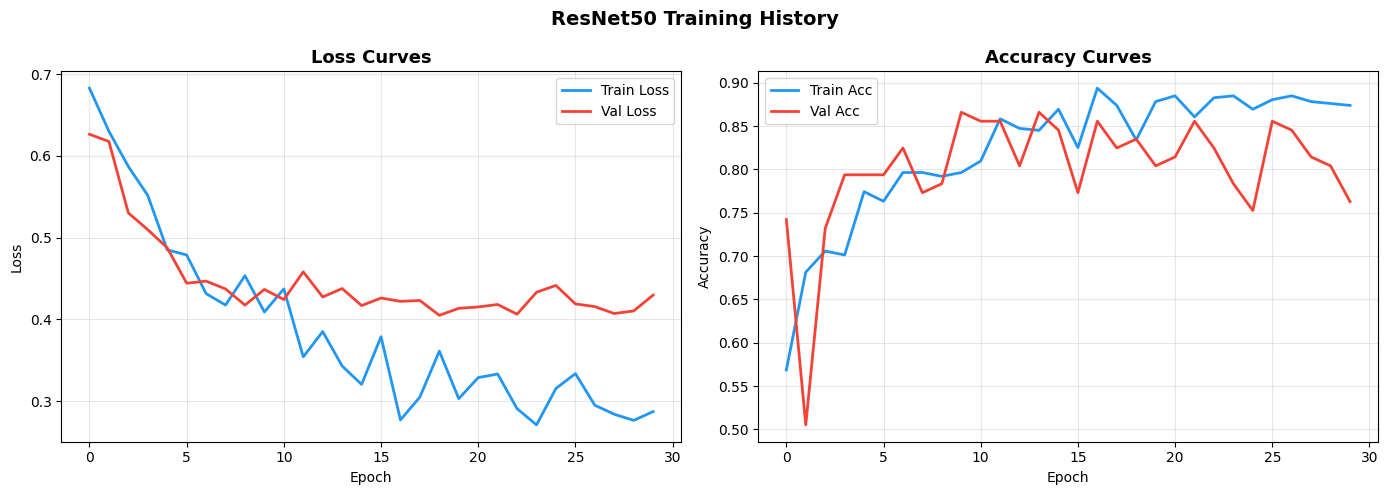

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#2196F3', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#F44336', linewidth=2)
axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='#2196F3', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val Acc',   color='#F44336', linewidth=2)
axes[1].set_title('Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('ResNet50 Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels_list = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_preds = np.array(all_preds)
all_labels_list = np.array(all_labels_list)
all_probs = np.array(all_probs)

print("Test evaluation complete")
print(f"Test samples: {len(all_preds)}")

Test evaluation complete
Test samples: 98


In [50]:
print("=" * 55)
print("        IMAGING MODEL — TEST RESULTS")
print("=" * 55)
print(classification_report(all_labels_list, all_preds,
                             target_names=['Benign', 'Malignant']))

        IMAGING MODEL — TEST RESULTS
              precision    recall  f1-score   support

      Benign       0.90      0.82      0.86        66
   Malignant       0.68      0.81      0.74        32

    accuracy                           0.82        98
   macro avg       0.79      0.82      0.80        98
weighted avg       0.83      0.82      0.82        98



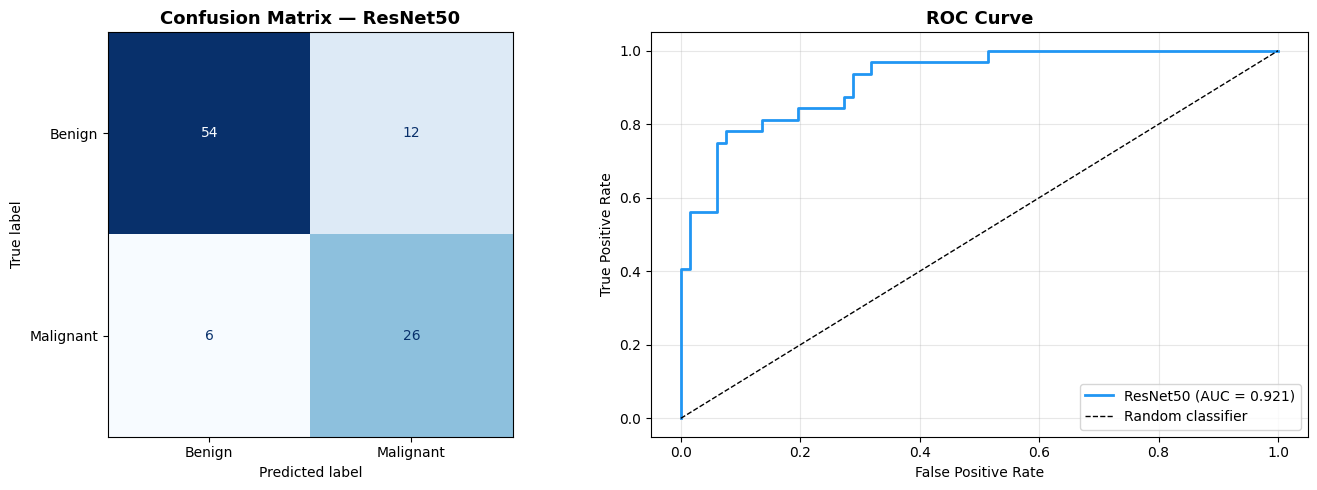


AUC Score: 0.9209


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels_list, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — ResNet50', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(all_labels_list, all_probs)
auc_score = roc_auc_score(all_labels_list, all_probs)

axes[1].plot(fpr, tpr, color='#2196F3', linewidth=2,
             label=f'ResNet50 (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('imaging_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAUC Score: {auc_score:.4f}")

In [52]:
import json

imaging_results = {
    'model': 'ResNet50',
    'test_accuracy': float((all_preds == all_labels_list).mean()),
    'auc': float(auc_score),
    'test_probs': all_probs.tolist(),
    'test_labels': all_labels_list.tolist(),
    'test_preds': all_preds.tolist()
}

with open('imaging_results.json', 'w') as f:
    json.dump(imaging_results, f)

print(f"Test Accuracy: {imaging_results['test_accuracy']:.4f}")
print(f"AUC:           {imaging_results['auc']:.4f}")
print("Results saved to imaging_results.json — needed for Task 4 fusion model")

Test Accuracy: 0.8163
AUC:           0.9209
Results saved to imaging_results.json — needed for Task 4 fusion model


In [53]:
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0.5
best_acc = 0.0

for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    acc = accuracy_score(all_labels_list, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}")
print(f"Best accuracy:  {best_acc:.4f}")

Best threshold: 0.70
Best accuracy:  0.8776


In [54]:
final_preds = (all_probs >= best_thresh).astype(int)

print("=" * 55)
print("   OPTIMISED THRESHOLD — TEST RESULTS")
print("=" * 55)
print(f"Threshold: {best_thresh:.2f}")
print(classification_report(all_labels_list, final_preds,
                             target_names=['Benign', 'Malignant']))

   OPTIMISED THRESHOLD — TEST RESULTS
Threshold: 0.70
              precision    recall  f1-score   support

      Benign       0.90      0.92      0.91        66
   Malignant       0.83      0.78      0.81        32

    accuracy                           0.88        98
   macro avg       0.87      0.85      0.86        98
weighted avg       0.88      0.88      0.88        98

